# This notebook contains info on the Dynamical decomposition for JJAS versus JA

Important results are the change in R2 when including 14 more days, and 2 more months. This drops significantly.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sklearn.linear_model import Ridge
import pandas as pd
import os
%matplotlib inline

In [2]:
os.chdir("/home/thappe/HeaT")

from HeaT.dyn_decomp import *

In [3]:
data_path = "/home/thappe/data/"

In [4]:
ls /home/thappe/data/ 

ERA5/       ML_prep_MSLP_STREAM/  T2M_decomposition/  VAE_MODEL/
heatwaves/  NASA_GMST.csv         tf_records/


In [5]:
ls /home/thappe/data/T2M_decomposition

 90th_percentile/
 JJA/
 T2M_dynamic_westEU_LENTIS_june23-sept7_1940-2023_90pctl15d_CDO.nc
 T2M_dynamic_westEU_LENTIS_june23-sept7_1940-2023.nc
 T2M_minus_thermo_westEU_LENTIS_1940-2023.nc
 T2M_minus_thermo_westEU_LENTIS_JA_1940-2023_90pctl15d_CDO.nc
 T2M_minus_thermo_westEU_LENTIS_JA_1940-2023.nc
 T2M_minus_thermo_westEU_LENTIS_june23-sept7_1940-2023_90pctl15d_CDO.nc
 T2M_minus_thermo_westEU_LENTIS_june23-sept7_1940-2023.nc
'T2M_westEU_JJAS_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10.nc'
'T2M_westEU_JJAS_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10_temp_only.nc'
'T2M_westEU_June23-JA-Sept7_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10.nc'
'the410@ada.labs.vu.nl'


In [ ]:
#"T2M_westEU_June23-JA-Sept7_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10.nc"

##  ERA5 Data

In [8]:
T2M_file = "1940-2023_T2M_westEU_JJAS_LENTISGRID.nc"
STREAM500_file = "STREAM500_era5_ExtendedWestEU_0.25degr_1940_2023_JJAS.nc"

In [9]:
t2m = xr.open_dataset(f"{data_path}{T2M_file}")["t2m"] - 273.15
stream500 = xr.open_dataset(f"{data_path}{STREAM500_file}")

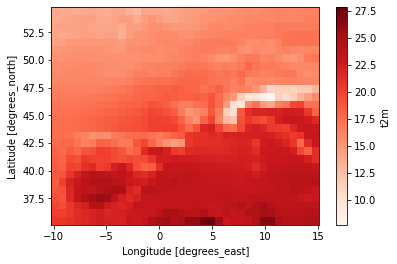

In [10]:
t2m_climatology = t2m.mean(dim="time")
t2m_climatology.plot(cmap="Reds")


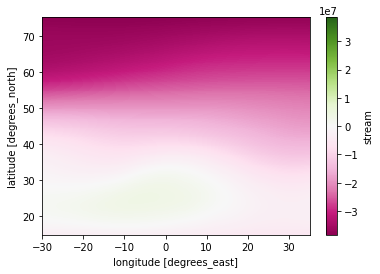

In [11]:
stream500_clim = stream500['stream'].mean(dim="time")
stream500_clim.plot(cmap="PiYG")

## NASA yearly GMST --> moet dit nog grotere lowess?

Perhaps a sensitivity test later on lowess=50 or so

In [7]:
yearly_GMST = pd.read_csv(f"{data_path}NASA_GMST.csv", delimiter=";", skiprows=1, index_col=0)

<AxesSubplot:xlabel='Year'>

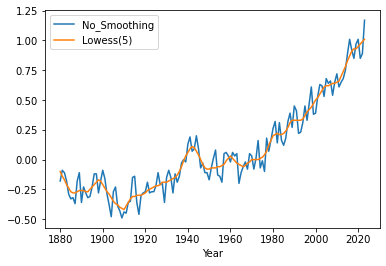

In [8]:
yearly_GMST.plot()

# To read in the decomposed t2m data 

In [12]:
ls /home/thappe/data/T2M_decomposition/

 JJA/
'T2M_westEU_JJAS_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10.nc'
'T2M_westEU_JJAS_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10_Tdyn_90thPctl_15d.nc'
'T2M_westEU_JJAS_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10_temp_only.nc'


In [6]:
t2m_decomped_file = "T2M_westEU_JJAS_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10.nc"
fileshort = "JJAS"


t2m_decomped_file = "T2M_westEU_June23-JA-Sept7_LENTIS=True_decomposed_1940-2023_window=20_CV=False_alpha=10.nc"
fileshort = "June 23rd - Sept 7th"

In [7]:
t2m_decom = xr.open_dataset(f"{data_path}/T2M_decomposition/{t2m_decomped_file}")

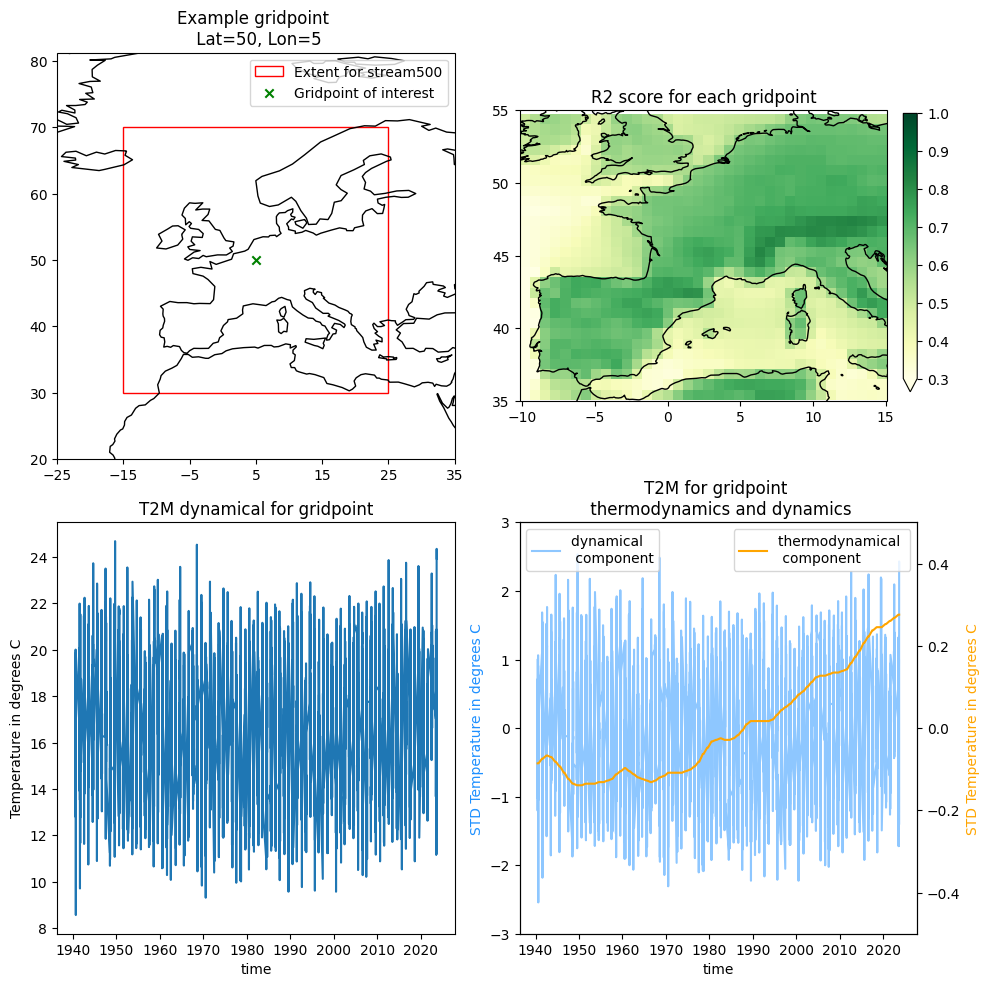

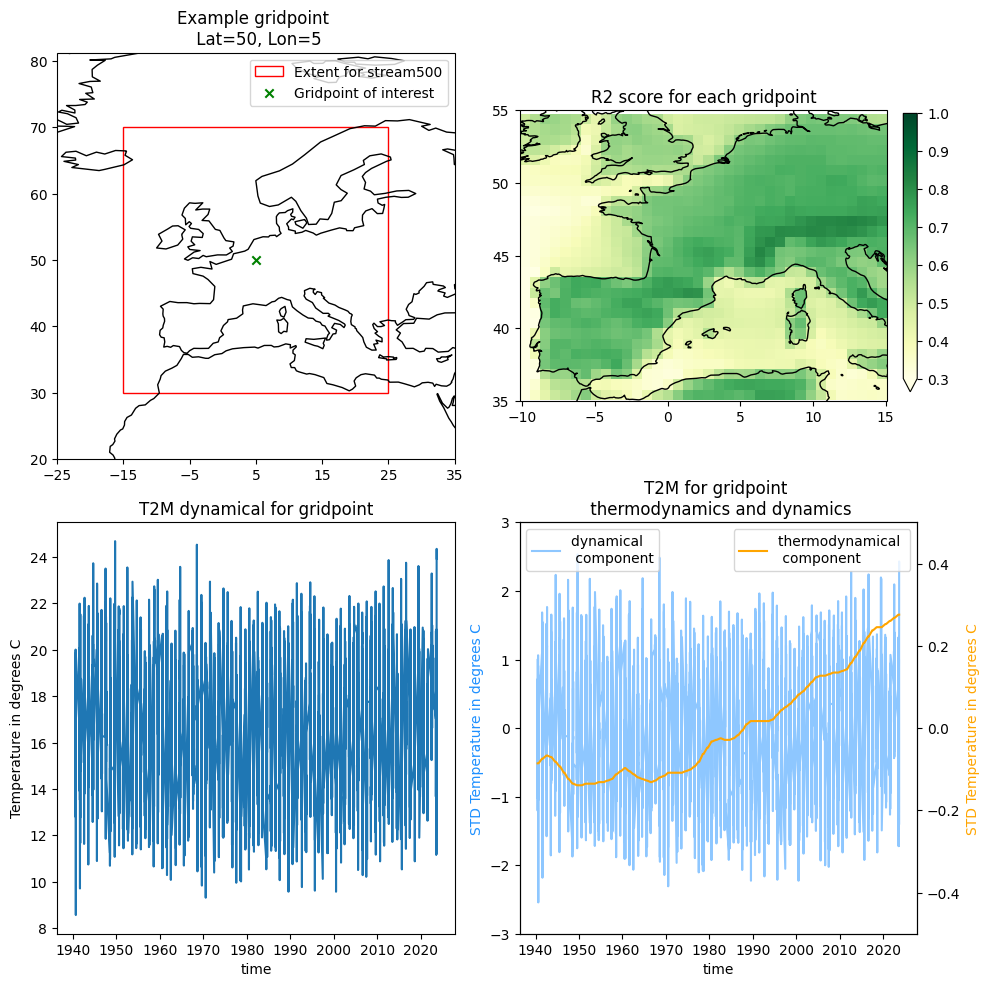

In [51]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
%matplotlib inline

lon, lat = 5, 50
window=20
lon_bounds = (lon-window, lon+window)
lat_bounds = (lat-window, lat+window)


### PLOT

fig = plt.figure(figsize=(10,10))
gs = fig.add_gridspec(6, 6)

ax1 = fig.add_subplot(gs[0:3, 0:3], projection=ccrs.PlateCarree())
size=10
ax1.set_extent([lon-(window+size), lon+(window+size), lat-(window+size), lat+(window+size)])
ax1.add_patch(mpatches.Rectangle(xy=[lon_bounds[0],lat_bounds[0]], width=window*2, height=window*2,
                                facecolor='none', edgecolor='red',
                                transform=ccrs.PlateCarree(), label="Extent for stream500"))
ax1.coastlines()
ax1.scatter(lon,lat, transform=ccrs.PlateCarree(), color='g', marker='x', label="Gridpoint of interest")

ax1.legend()
# ax1.set_title("T2M gridpoint to predict \n and extent for dynamics")
ax1.set_title(f"Example gridpoint \n Lat={lat}, Lon={lon}")
ax1.set_xticks(np.arange(lon-(window+10), lon+(window+10+1), 10))
ax1.set_yticks(np.arange(lat-(window+10), lat+(window+10+1), 10))


####

ax2 = fig.add_subplot(gs[0:3, 3:6], projection=ccrs.PlateCarree())
pc = ax2.pcolormesh(t2m_decom["R2"].longitude,t2m_decom["R2"].latitude,t2m_decom["R2"].values,
                    vmin=0.3, vmax=1, cmap="YlGn") #YlGnBu
fig.colorbar(pc, ax=ax2, fraction=0.035, pad=0.04, extend='min')
ax2.coastlines()
ax2.set_title("R2 score for each gridpoint")
ax2.set_xticks(np.arange(-10, 16, 5))
ax2.set_yticks(np.arange(35, 56, 5))

ax3 = fig.add_subplot(gs[3:6, 0:3])
ax3.plot(t2m_decom["T2M_dynamic"].time, t2m_decom["T2M_dynamic"].sel(latitude=lat, longitude=lon, method="nearest"))
ax3.set_title("T2M dynamical for gridpoint")
ax3.set_xlabel("time")
ax3.set_ylabel("Temperature in degrees C")



ax4 = fig.add_subplot(gs[3:6, 3:6])
ax5 = ax4.twinx()
ax4.plot(t2m_decom["T2M_dynamical_std"].time, t2m_decom["T2M_dynamical_std"].sel(latitude=lat, longitude=lon, method="nearest"), 
         label="dynamical \n component", alpha=0.5, c="dodgerblue")
ax5.plot(t2m_decom["T2M_thermodynamic_std"].time, t2m_decom["T2M_thermodynamic_std"].sel(latitude=lat, longitude=lon, method="nearest"), 
         label="thermodynamical \n component", c="orange")

ax4.set_title("T2M for gridpoint \n thermodynamics and dynamics")
ax4.set_xlabel("time")
ax4.set_ylabel("STD Temperature in degrees C", c="dodgerblue")
ax5.set_ylabel("STD Temperature in degrees C", c="orange")
ax5.set_ylim(-0.5, 0.5)
ax4.set_ylim(-3, 3)
ax4.legend(loc="upper left")
ax5.legend()

# fig.suptitle(f"{fileshort} Lat={lat}, Lon={lon}")
fig.tight_layout()

fig.savefig("/home/thappe/HeaT/Figures/DynDecomp_A1.png", dpi=400)
plt.show()

Text(0.5, 1.0, 'R2 scores')

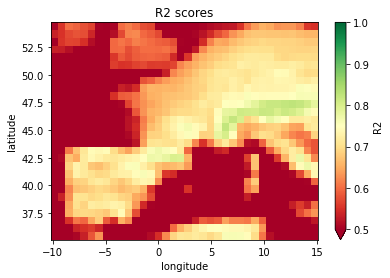

In [65]:
r2_j2s = t2m_decom["R2"]
t2m_decom["R2"].plot(cmap="RdYlGn", vmin=.5, vmax=1)
plt.title("R2 scores")

In [24]:
ls /home/thappe/data/T2M_decomposition/JJA

'T2M_westEU_LENTIS=True_decomposed_1940-2022_window=20_CV=False_alpha=10.nc'
'T2M_westEU_LENTIS=True_decomposed_1940-2022_window=20_CV=False_alpha=10_Tdyn_90thPctl_15d.nc'
'T2M_westEU_LENTIS=True_decomposed_1940-2022_window=20_CV=False_alpha=10_temp_only.nc'
'T2M_westEU_LENTIS=True_decomposed_1940-2022_window=20_CV=False_alpha=10_test.nc'


In [25]:
t2m_decomped_file = "T2M_westEU_LENTIS=True_decomposed_1940-2022_window=20_CV=False_alpha=10.nc"
fileshort = "JA"
t2m_decom = xr.open_dataset(f"{data_path}/T2M_decomposition/JJA/{t2m_decomped_file}")

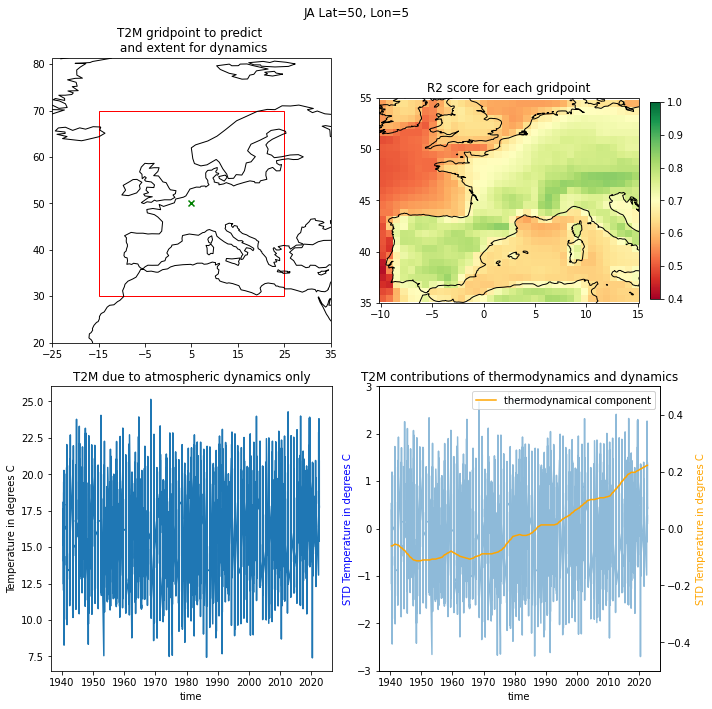

In [26]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches


lon, lat = 5, 50
window=20
lon_bounds = (lon-window, lon+window)
lat_bounds = (lat-window, lat+window)


### PLOT

fig = plt.figure(figsize=(10,10))
gs = fig.add_gridspec(6, 6)

ax1 = fig.add_subplot(gs[0:3, 0:3], projection=ccrs.PlateCarree())
ax1.set_extent([lon-(window+10), lon+(window+10), lat-(window+10), lat+(window+10)])
ax1.add_patch(mpatches.Rectangle(xy=[lon_bounds[0],lat_bounds[0]], width=window*2, height=window*2,
                                facecolor='none', edgecolor='red',
                                transform=ccrs.PlateCarree()))
ax1.coastlines()
ax1.scatter(lon,lat, transform=ccrs.PlateCarree(), color='g', marker='x')
ax1.set_title("T2M gridpoint to predict \n and extent for dynamics")
ax1.set_xticks(np.arange(lon-(window+10), lon+(window+10+1), 10))
ax1.set_yticks(np.arange(lat-(window+10), lat+(window+10+1), 10))


####

ax2 = fig.add_subplot(gs[0:3, 3:6], projection=ccrs.PlateCarree())
pc = ax2.pcolormesh(t2m_decom["R2"].longitude,t2m_decom["R2"].latitude,t2m_decom["R2"].values,
                    vmin=0.4, vmax=1, cmap="RdYlGn")
fig.colorbar(pc, ax=ax2, fraction=0.035, pad=0.04)
ax2.coastlines()
ax2.set_title("R2 score for each gridpoint")
ax2.set_xticks(np.arange(-10, 16, 5))
ax2.set_yticks(np.arange(35, 56, 5))

ax3 = fig.add_subplot(gs[3:6, 0:3])
ax3.plot(t2m_decom["T2M_dynamic"].time, t2m_decom["T2M_dynamic"].sel(latitude=lat, longitude=lon, method="nearest"))
ax3.set_title("T2M due to atmospheric dynamics only")
ax3.set_xlabel("time")
ax3.set_ylabel("Temperature in degrees C")



ax4 = fig.add_subplot(gs[3:6, 3:6])
ax5 = ax4.twinx()
ax4.plot(t2m_decom["T2M_dynamical_std"].time, t2m_decom["T2M_dynamical_std"].sel(latitude=lat, longitude=lon, method="nearest"), 
         label="dynamical component", alpha=0.5)
ax5.plot(t2m_decom["T2M_thermodynamic_std"].time, t2m_decom["T2M_thermodynamic_std"].sel(latitude=lat, longitude=lon, method="nearest"), 
         label="thermodynamical component", c="orange")

ax4.set_title("T2M contributions of thermodynamics and dynamics")
ax4.set_xlabel("time")
ax4.set_ylabel("STD Temperature in degrees C", c="blue")
ax5.set_ylabel("STD Temperature in degrees C", c="orange")
ax5.set_ylim(-0.5, 0.5)
ax4.set_ylim(-3, 3)
ax4.legend()
ax5.legend()

fig.suptitle(f"{fileshort} Lat={lat}, Lon={lon}")
fig.tight_layout()

Text(0.5, 1.0, 'R2 scores - JA')

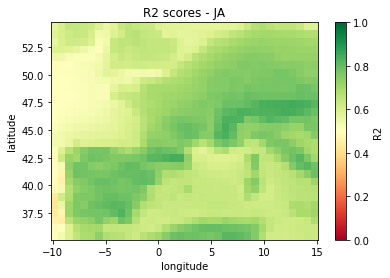

In [27]:
R2_JA = t2m_decom["R2"]
t2m_decom["R2"].plot(cmap="RdYlGn", vmin=0, vmax=1)
plt.title(f"R2 scores - {fileshort}")

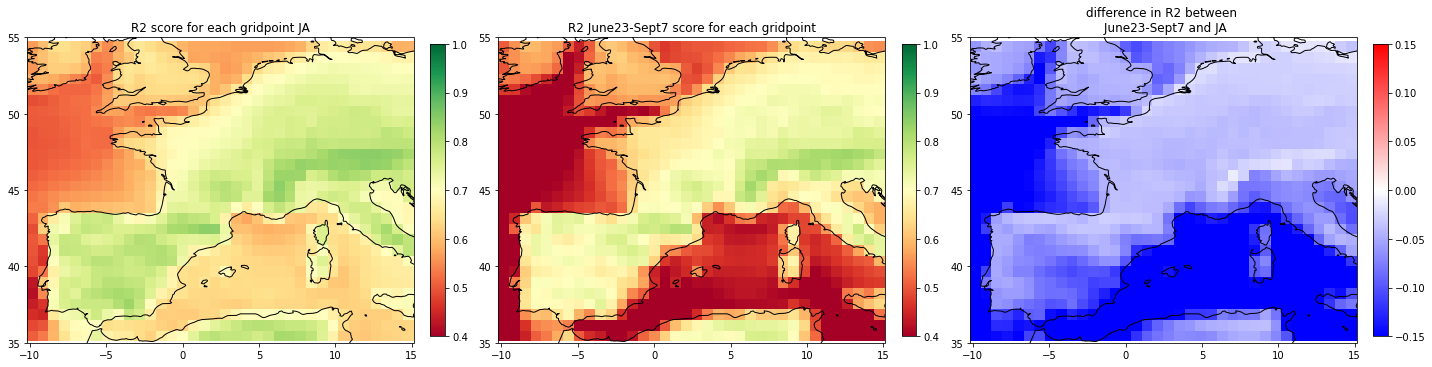

In [38]:
fig = plt.figure(figsize=(20,20))
gs = fig.add_gridspec(6, 9)

ax1 = fig.add_subplot(gs[0:6, 0:3], projection=ccrs.PlateCarree())
pc = ax1.pcolormesh(t2m_decom["R2"].longitude,t2m_decom["R2"].latitude, R2_JA,
                    vmin=0.4, vmax=1, cmap="RdYlGn")
fig.colorbar(pc, ax=ax1, fraction=0.035, pad=0.04)
ax1.coastlines()
ax1.set_title("R2 score for each gridpoint JA")
ax1.set_xticks(np.arange(-10, 16, 5))
ax1.set_yticks(np.arange(35, 56, 5))
####

ax2 = fig.add_subplot(gs[0:6, 3:6], projection=ccrs.PlateCarree())
pc = ax2.pcolormesh(t2m_decom["R2"].longitude,t2m_decom["R2"].latitude, r2_j2s,
                    vmin=0.4, vmax=1, cmap="RdYlGn")
fig.colorbar(pc, ax=ax2, fraction=0.035, pad=0.04)
ax2.coastlines()
ax2.set_title("R2 June23-Sept7 score for each gridpoint")
ax2.set_xticks(np.arange(-10, 16, 5))
ax2.set_yticks(np.arange(35, 56, 5))

ax3 = fig.add_subplot(gs[0:6, 6:9], projection=ccrs.PlateCarree())
pc = ax3.pcolormesh(t2m_decom["R2"].longitude,t2m_decom["R2"].latitude, r2_j2s-R2_JA,
                    vmin=-0.15, vmax=0.15, cmap="bwr")
fig.colorbar(pc, ax=ax3, fraction=0.035, pad=0.04)
ax3.coastlines()
ax3.set_title("difference in R2 between \n June23-Sept7 and JA")
ax3.set_xticks(np.arange(-10, 16, 5))
ax3.set_yticks(np.arange(35, 56, 5))

fig.tight_layout()

### losse snippets

Text(0.5, 1.0, 'Coefficients of dynamical part of the regression \n for T2M in gridpoint denoted with X')

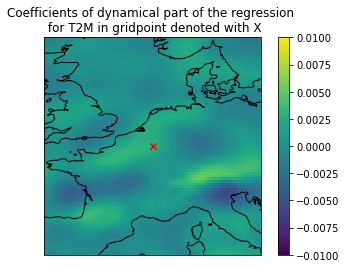

In [45]:
fig,ax = plt.subplots(nrows=1, ncols=1, figsize=(6,4), 
                      subplot_kw={'projection': ccrs.PlateCarree()})

ax.set_extent([lon-(10), lon+(10), lat-(10), lat+(10)])
ax.add_patch(mpatches.Rectangle(xy=[lon_bounds[0],lat_bounds[0]], width=window*2, height=window*2,
                                facecolor='none', edgecolor='red',
                                transform=ccrs.PlateCarree()))
cs = ax.pcolormesh(stream500_cut.longitude, stream500_cut.latitude, 
              stream_weigths_reshaped,
             vmin=-0.01, vmax=0.01)
fig.colorbar(cs, ax=ax)

ax.coastlines()
ax.scatter(lon,lat, transform=ccrs.PlateCarree(), color='r', marker='x')
plt.title("Coefficients of dynamical part of the regression \n for T2M in gridpoint denoted with X")

In [46]:
## dus dan kun je daarna met de GMSTw de temperatuur eruit halen die 
## door thermodynamics komt, voor elke dag, en dan heb je de detrended timeseries voor t2m
print(np.sum(stream_weigths_reshaped))
GMSTw

0.46996392530280173


0.10700090009619277

## predict the (standardized) temperature from the weights

##### thermodynamic component of temperature

In [70]:
T2M_dynamical = (stream_weigths_reshaped * stream500_x2).sum(dim=("longitude", "latitude"))
T2M_dynamical = T2M_dynamical.rename("T2M_dynamical")
T2M_dynamical.assign_attrs(units="Celsius", description="Standardized temperature data")

<xarray.DataArray 'T2M_dynamical' (time: 7636)>
array([-1.25363925, -0.41114392,  0.36928295, ...,  0.46976877,
        0.35349404,  0.42125191])
Coordinates:
  * time     (time) datetime64[ns] 1940-06-01T11:00:00 ... 2022-08-31T11:00:00
Attributes:
    units:        Celsius
    description:  Standardized temperature data

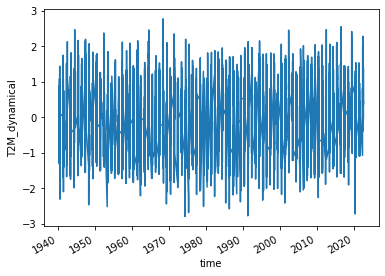

In [71]:
T2M_dynamical.plot()

##### thermodynamic component of temperature

In [77]:
T2M_thermodynamical = GMSTw * GSMT_x1
T2M_thermodynamical = T2M_thermodynamical.rename("T2M_thermodynamical")
T2M_thermodynamical.assign_attrs(units="Celsius", description="Standardized temperature data")

<xarray.DataArray 'T2M_thermodynamical' (time: 7636)>
array([-0.06371696, -0.06371696, -0.06371696, ...,  0.23241373,
        0.23241373,  0.23241373])
Coordinates:
  * time     (time) int64 1940 1940 1940 1940 1940 ... 2022 2022 2022 2022 2022
Attributes:
    units:        Celsius
    description:  Standardized temperature data

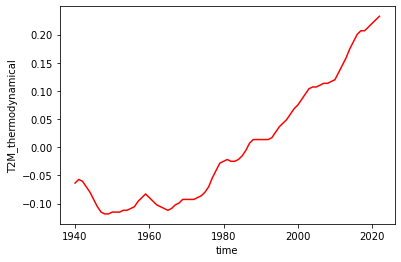

In [85]:
T2M_thermodynamical.plot(c="red", label="thermodynamic component of T")


Text(0, 0.5, 'Degrees C')

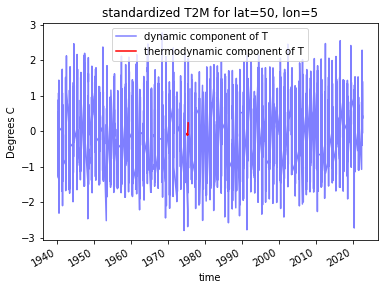

In [87]:
# T2M_thermodynamical.plot(c="red", label="thermodynamic component of T")

T2M_dynamical.plot(c="blue", label="dynamic component of T", alpha=0.5)
T2M_thermodynamical.plot(c="red", label="thermodynamic component of T")

plt.title(f"standardized T2M for lat={lat}, lon={lon}")
plt.legend()
plt.ylabel("Degrees C")

Text(0.5, 0.98, 'Lat=50, Lon=5')

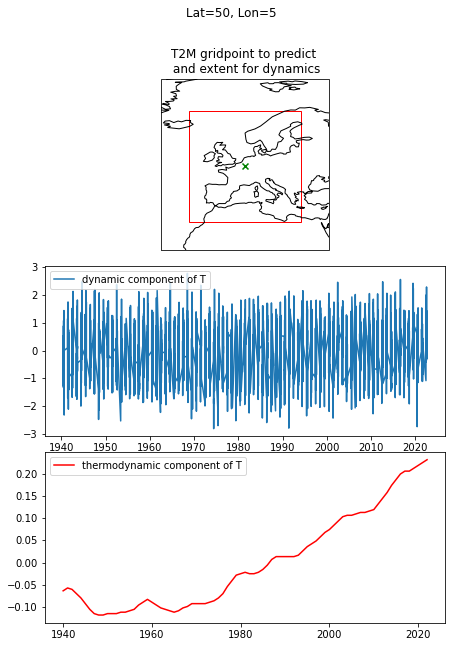

In [115]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(15,10))
gs = fig.add_gridspec(6, 4)

ax1 = fig.add_subplot(gs[0:2, :], projection=ccrs.PlateCarree())
ax1.set_extent([lon-(window+10), lon+(window+10), lat-(window+10), lat+(window+10)])
ax1.add_patch(mpatches.Rectangle(xy=[lon_bounds[0],lat_bounds[0]], width=window*2, height=window*2,
                                facecolor='none', edgecolor='red',
                                transform=ccrs.PlateCarree()))
ax1.coastlines()
ax1.scatter(lon,lat, transform=ccrs.PlateCarree(), color='g', marker='x')

ax1.set_title("T2M gridpoint to predict \n and extent for dynamics")

####

ax2 = fig.add_subplot(gs[2:4, 1:3])
ax2.plot(T2M_dynamical.time, T2M_dynamical.values, label="dynamic component of T")
ax2.legend(loc="upper left")

ax3 = fig.add_subplot(gs[4:, 1:3])
ax3.plot(T2M_thermodynamical.time, T2M_thermodynamical.values, label="thermodynamic component of T", c="r")

ax3.legend(loc="upper left")

fig.suptitle(f"Lat={lat}, Lon={lon}")